# 03 — Baseline Analysis

Train and evaluate the econometric and ML baselines on a single walk-forward fold.
Compares: Persistence, GARCH(1,1), EGARCH, HAR-RV, LightGBM/XGBoost.

**Prerequisites:** Run `make data` to build processed tensors, or provide your own returns series.

In [4]:
import sys
import os
from pathlib import Path
if Path(os.getcwd()).name == 'notebooks':
    os.chdir('..')
sys.path.append(os.path.abspath('src'))
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

from volregime.utils.config import load_config

cfg = load_config()
data_dir = Path('data/liquid_core')
raw_dir = data_dir / 'raw'
canonical_dir = data_dir / 'canonical'
horizon = cfg['data']['targets']['forward_horizon']  # 21 days
print(f"Forecast horizon: {horizon} trading days")

Forecast horizon: 21 trading days


## 1. Prepare Realized Volatility Series

In [5]:
symbol = cfg['active_symbols_list'][0]

# Load from canonical (already has log_return) or raw underlying cache
canonical_path = canonical_dir / 'underlying_canonical.parquet'
raw_underlying_path = raw_dir / 'underlying_all.parquet'

undl = None
if canonical_path.exists():
    undl_all = pd.read_parquet(canonical_path)
    undl_all['date'] = pd.to_datetime(undl_all['date'])
    # Filter to main symbol
    sym_col = 'symbol' if 'symbol' in undl_all.columns else 'act_symbol'
    if symbol in undl_all[sym_col].values:
        undl = undl_all[undl_all[sym_col] == symbol].copy()
    else:
        undl = undl_all.copy()  # use all if symbol not found
    print(f"Loaded from canonical: {len(undl)} rows")
elif raw_underlying_path.exists():
    undl_all = pd.read_parquet(raw_underlying_path)
    undl_all['date'] = pd.to_datetime(undl_all['date'])
    sym_col = 'symbol' if 'symbol' in undl_all.columns else 'act_symbol'
    undl = undl_all[undl_all[sym_col] == symbol].copy() if symbol in undl_all[sym_col].values else undl_all.copy()
    print(f"Loaded from raw: {len(undl)} rows")
else:
    raise FileNotFoundError(f"No underlying data found. Run `make fetch` first.")

# underlying_canonical already has log_return column
if 'log_return' not in undl.columns:
    close_col = 'adj_close' if 'adj_close' in undl.columns else 'close'
    undl = undl.sort_values('date').copy()
    undl['log_return'] = np.log(undl[close_col] / undl[close_col].shift(1))

undl = undl.sort_values('date').dropna(subset=['log_return']).reset_index(drop=True)
print(f"{symbol}: {len(undl)} trading days")

# Compute trailing and forward RV
log_rets = undl['log_return'].values
trailing_rv  = pd.Series(log_rets).rolling(horizon).apply(lambda x: np.sqrt((x**2).sum()), raw=True).values
forward_rv   = pd.Series(log_rets).shift(-horizon).rolling(horizon).apply(lambda x: np.sqrt((x**2).sum()), raw=True).values

# Align: need both trailing and forward to be non-NaN
valid = ~(np.isnan(trailing_rv) | np.isnan(forward_rv))
dates_all   = pd.to_datetime(undl['date'])[valid].values
trailing    = trailing_rv[valid]
forward     = forward_rv[valid]
log_forward = np.log(np.maximum(forward, 1e-10))
returns_valid = log_rets[valid]

# Train/test split: last 20% as test
n = len(trailing)
split = int(n * 0.8)
print(f"Train: {split}, Test: {n - split}")

Loaded from canonical: 3026 rows
SPY: 3025 trading days
Train: 2387, Test: 597


## 2. Persistence Baseline

In [6]:
from volregime.baselines.persistence import PersistanceBaseline
from volregime.evaluation.forecast_metrics import compute_vol_metrics

persist = PersistanceBaseline()
persist_pred = persist.predict(trailing[split:])
persist_log_pred = np.log(np.maximum(persist_pred, 1e-10))

persist_metrics = compute_vol_metrics(persist_log_pred, log_forward[split:], rv_prev=trailing[split:])
print("Persistence:")
for k, v in persist_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Persistence:
  qlike: -5.1544
  ql: 0.1907
  mape: 0.3619
  r2: -0.3644
  bias: 0.0000
  rmse: 0.0259
  n: 597
  hit_rate: 0.5025


## 3. GARCH(1,1) and EGARCH

In [7]:
from volregime.baselines.garch import GARCHBaseline, EGARCHBaseline

# GARCH(1,1) — rolling refit every 21 days
garch = GARCHBaseline(p=1, q=1, horizon=horizon)
garch.fit(returns_valid[:split])

garch_preds = []
for i in range(split, n):
    if (i - split) % 21 == 0:
        garch.fit(returns_valid[:i])
    garch_preds.append(garch.predict())
garch_preds = np.array(garch_preds)
garch_log_preds = np.log(np.maximum(garch_preds, 1e-10))

garch_metrics = compute_vol_metrics(garch_log_preds, log_forward[split:])
print("GARCH(1,1):")
for k, v in garch_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

GARCH(1,1):
  qlike: -5.2988
  ql: 0.1654
  mape: 0.3766
  r2: 0.0305
  bias: 0.0038
  rmse: 0.0219
  n: 597


In [10]:
# EGARCH — use 1-step ahead forecasts (analytic not available for horizon > 1)
egarch = EGARCHBaseline(p=1, q=1, horizon=1)

egarch_preds = []
for i in range(split, n):
    if (i - split) % 21 == 0:
        egarch.fit(returns_valid[:i])
    egarch_preds.append(egarch.predict())
egarch_preds = np.array(egarch_preds)
egarch_log_preds = np.log(np.maximum(egarch_preds, 1e-10))

egarch_metrics = compute_vol_metrics(egarch_log_preds, log_forward[split:])
print("EGARCH (1-step ahead):")
for k, v in egarch_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

EGARCH (1-step ahead):
  qlike: 18.6739
  ql: 2.3745
  mape: 0.7531
  r2: -1.8403
  bias: -0.0308
  rmse: 0.0374
  n: 597


## 4. HAR-RV

In [11]:
from volregime.baselines.har_rv import HARRVBaseline

har = HARRVBaseline()
har.fit(trailing[:split], forward[:split])
print(f"HAR-RV coefficients: daily={har.coef_[0]:.3f}, weekly={har.coef_[1]:.3f}, monthly={har.coef_[2]:.3f}")
print(f"Intercept: {har.intercept_:.4f}")
print(f"In-sample R2: {har.train_r2_:.4f}")

# predict_series returns array same length as input, with NaN warmup for first ~21 values
har_pred = har.predict_series(trailing[split:])
har_valid = ~np.isnan(har_pred)
har_log_pred = np.log(np.maximum(har_pred[har_valid], 1e-10))

har_metrics = compute_vol_metrics(har_log_pred, log_forward[split:][har_valid])
print("\nHAR-RV (out-of-sample):")
for k, v in har_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

HAR-RV coefficients: daily=2.262, weekly=-1.920, monthly=0.180
Intercept: 0.0205
In-sample R2: 0.3260

HAR-RV (out-of-sample):
  qlike: 585119202736015.2500
  ql: 1.5109
  mape: 0.3425
  r2: 0.0470
  bias: 0.0019
  rmse: 0.0220
  n: 577


## 5. Diebold-Mariano Tests

In [12]:
from volregime.evaluation.stat_tests import diebold_mariano
from volregime.evaluation.forecast_metrics import qlike

test_log_rv = log_forward[split:]

def per_sample_qlike(log_pred, log_true):
    return np.array([qlike(np.array([log_pred[i]]), np.array([log_true[i]])) for i in range(len(log_pred))])

# Align lengths to shortest test set
n_test = min(len(persist_log_pred), len(garch_log_preds), len(egarch_log_preds))

losses = {
    'Persistence': per_sample_qlike(persist_log_pred[:n_test], test_log_rv[:n_test]),
    'GARCH':       per_sample_qlike(garch_log_preds[:n_test],  test_log_rv[:n_test]),
    'EGARCH':      per_sample_qlike(egarch_log_preds[:n_test], test_log_rv[:n_test]),
    'HAR-RV':      per_sample_qlike(har_log_pred,              log_forward[split:][har_valid]),
}

print(f"{'Model A':>12} vs {'Model B':>12}  |  DM stat  |  p-value  |  Significant")
print("-" * 72)

pairs = [
    ('HAR-RV', 'Persistence'),
    ('GARCH',  'Persistence'),
    ('EGARCH', 'Persistence'),
    ('HAR-RV', 'GARCH'),
    ('HAR-RV', 'EGARCH'),
]

for a_name, b_name in pairs:
    a_loss = losses[a_name]
    b_loss = losses[b_name]
    min_len = min(len(a_loss), len(b_loss))
    dm, pval = diebold_mariano(a_loss[:min_len], b_loss[:min_len], h=horizon)
    sig    = '*' if pval < 0.05 else ''
    winner = a_name if dm < 0 else b_name
    print(f"{a_name:>12} vs {b_name:>12}  |  {dm:+7.3f}  |  {pval:.4f}    |  {sig} {winner if sig else ''}")

     Model A vs      Model B  |  DM stat  |  p-value  |  Significant
------------------------------------------------------------------------
      HAR-RV vs  Persistence  |   +1.030  |  0.3032    |   
       GARCH vs  Persistence  |   -1.676  |  0.0937    |   
      EGARCH vs  Persistence  |   +5.724  |  0.0000    |  * Persistence
      HAR-RV vs        GARCH  |   +1.030  |  0.3032    |   
      HAR-RV vs       EGARCH  |   +1.030  |  0.3032    |   


## 6. Mincer-Zarnowitz Efficiency Test

In [13]:
from volregime.evaluation.stat_tests import mincer_zarnowitz

models_for_mz = {
    'Persistence': (persist_pred,            forward[split:]),
    'GARCH':       (garch_preds,              forward[split:]),
    'HAR-RV':      (har_pred[har_valid],      forward[split:][har_valid]),
}

mz_results = []
for name, (pred, true) in models_for_mz.items():
    mz = mincer_zarnowitz(pred, true)
    mz['model'] = name
    mz_results.append(mz)

mz_df = pd.DataFrame(mz_results).set_index('model')
print("Mincer-Zarnowitz: efficient forecast has intercept~0, slope~1, large R2")
print("F-test H0: (intercept=0, slope=1); small p -> forecast is biased/inefficient\n")
print(mz_df.round(4).to_string())

Mincer-Zarnowitz: efficient forecast has intercept~0, slope~1, large R2
F-test H0: (intercept=0, slope=1); small p -> forecast is biased/inefficient

             intercept   slope      r2    f_stat  f_pvalue    n
model                                                          
Persistence     0.0269  0.3177  0.1009  153.9549       0.0  597
GARCH           0.0137  0.5946  0.1131   27.7067       0.0  597
HAR-RV          0.0159  0.5697  0.1262   26.0688       0.0  577


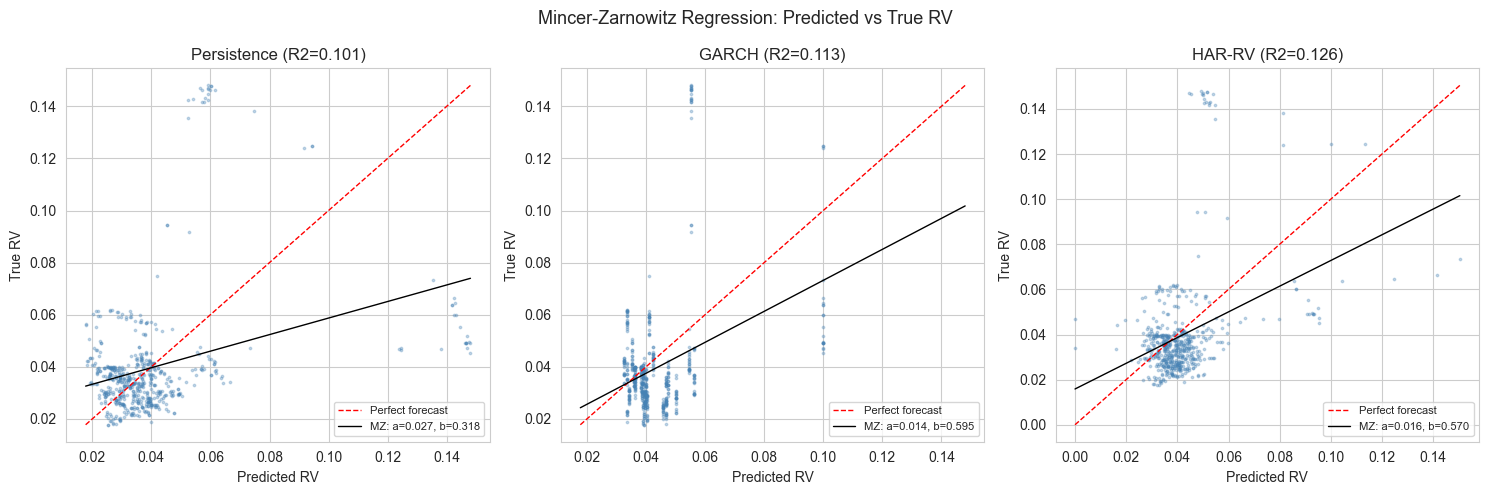

In [14]:
# MZ scatter plots
fig, axes = plt.subplots(1, len(models_for_mz), figsize=(5 * len(models_for_mz), 5))
if len(models_for_mz) == 1:
    axes = [axes]

for ax, (name, (pred, true)) in zip(axes, models_for_mz.items()):
    ax.scatter(pred, true, s=3, alpha=0.3, color='steelblue')
    lims = [min(pred.min(), true.min()), max(pred.max(), true.max())]
    ax.plot(lims, lims, 'r--', lw=1, label='Perfect forecast')

    mz_row = mz_df.loc[name]
    xs = np.linspace(lims[0], lims[1], 100)
    ax.plot(xs, mz_row['intercept'] + mz_row['slope'] * xs, 'k-', lw=1,
            label=f"MZ: a={mz_row['intercept']:.3f}, b={mz_row['slope']:.3f}")

    ax.set_title(f"{name} (R2={mz_row['r2']:.3f})")
    ax.set_xlabel('Predicted RV')
    ax.set_ylabel('True RV')
    ax.legend(fontsize=8)

plt.suptitle('Mincer-Zarnowitz Regression: Predicted vs True RV', fontsize=13)
plt.tight_layout()

## 7. Comparison Summary

In [15]:
all_metrics = {
    'Persistence': persist_metrics,
    'GARCH(1,1)':  garch_metrics,
    'EGARCH':      egarch_metrics,
    'HAR-RV':      har_metrics,
}

summary = pd.DataFrame(all_metrics).T
display_cols = ['qlike', 'ql', 'r2', 'rmse', 'mape', 'bias']
display_cols = [c for c in display_cols if c in summary.columns]
print(summary[display_cols].round(4).to_string())

                    qlike      ql      r2    rmse    mape    bias
Persistence -5.154400e+00  0.1907 -0.3644  0.0259  0.3619  0.0000
GARCH(1,1)  -5.298800e+00  0.1654  0.0305  0.0219  0.3766  0.0038
EGARCH       1.867390e+01  2.3745 -1.8403  0.0374  0.7531 -0.0308
HAR-RV       5.851192e+14  1.5109  0.0470  0.0220  0.3425  0.0019


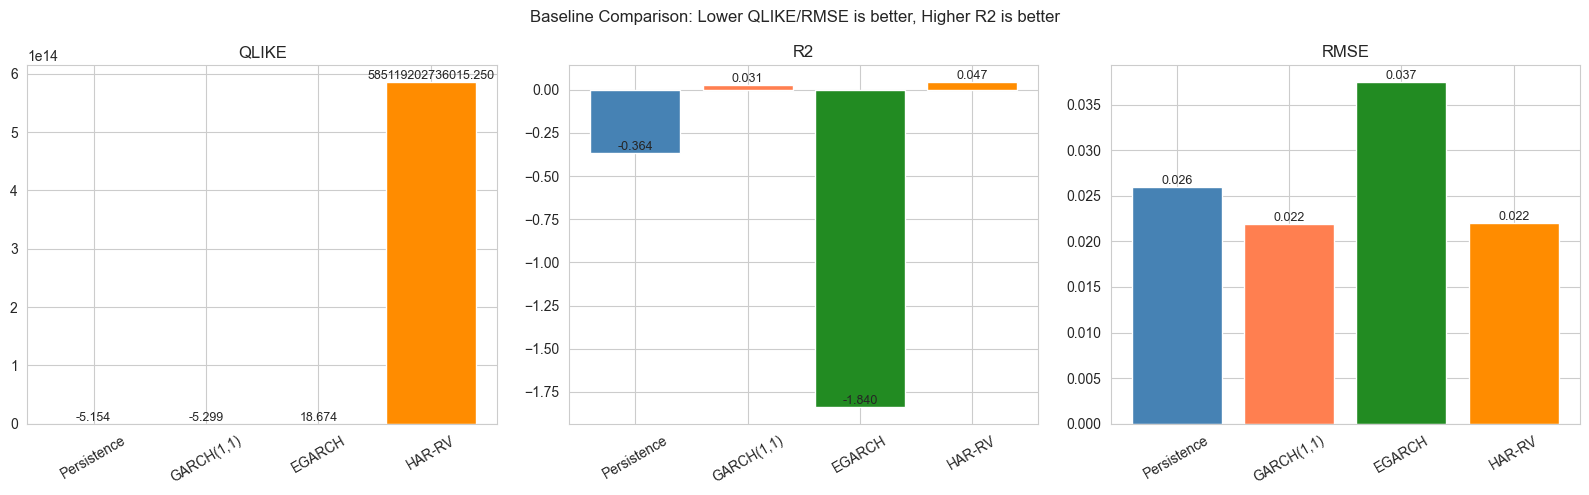

In [16]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_to_plot = ['qlike', 'r2', 'rmse']
colors = ['steelblue', 'coral', 'forestgreen', 'darkorange']

for ax, metric in zip(axes, metrics_to_plot):
    if metric in summary.columns:
        vals = summary[metric]
        bars = ax.bar(vals.index, vals.values, color=colors[:len(vals)])
        ax.set_title(metric.upper())
        ax.tick_params(axis='x', rotation=30)
        for bar, v in zip(bars, vals.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Baseline Comparison: Lower QLIKE/RMSE is better, Higher R2 is better', fontsize=12)
plt.tight_layout()

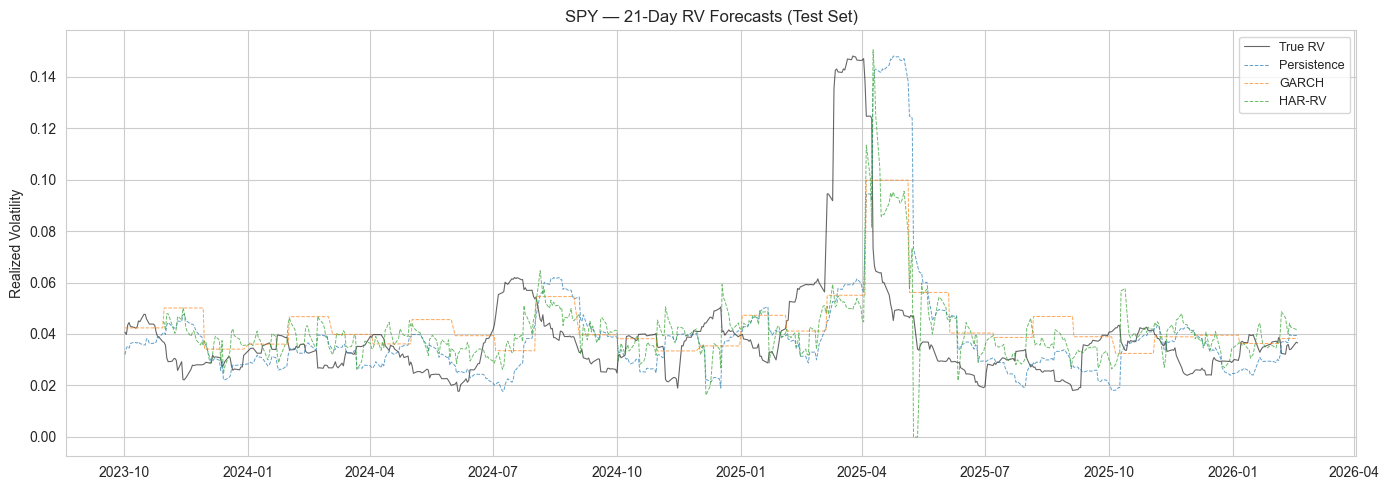

In [17]:
# Time series of predictions vs actual
test_dates = dates_all[split:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates, forward[split:], 'k-', lw=0.8, alpha=0.6, label='True RV')
ax.plot(test_dates, persist_pred, '--', lw=0.7, alpha=0.7, label='Persistence')
ax.plot(test_dates, garch_preds, '--', lw=0.7, alpha=0.7, label='GARCH')

# HAR-RV: needs offset for NaN warmup
# har_valid is a boolean mask over trailing[split:], same length
har_dates = test_dates[har_valid]
ax.plot(har_dates, har_pred[har_valid], '--', lw=0.7, alpha=0.7, label='HAR-RV')

ax.set_title(f'{symbol} — {horizon}-Day RV Forecasts (Test Set)')
ax.set_ylabel('Realized Volatility')
ax.legend(fontsize=9)
plt.tight_layout()